# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

#### Our Objective: 
To utilize a dataset containing information on used cars to make effective and valuable recommendations to our client, highlighting factors that affect the value of used cars, as well as what consumers value most when shopping for a used car. Our task will be to explore our dataset, prepare the data by ensuring that it is cleaned and properly formatted, identify features that impact the price of used cars most heavily using Feature Engineering, modeling our data using Linear Regression, Ridge Regression, and Lasso. We will evaluate the results, in order to coherently produce a clear and concise report with action items for our client.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

#### Import Appropriate Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

#### Import our Dataset

In [2]:
used_cars = pd.read_csv("vehicles.csv")

In [3]:
# View the header (top 5 rows of dataset) and explore columns, features and layout.
used_cars.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
# View the info of our dataset. Notice there are 426880 entries, and 18 columns.
# Of those 18 columns, 14 contain Objects, and all but 4 have NaN (non-null) entries.
# There's a lot of missing data here, and we will need to decide whether to drop, fill, or ignore.
used_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
# Checking to see how many unique values are in each category to help see complexity of data.
used_cars.nunique()

id              426880
region             404
price            15655
year               114
manufacturer        42
model            29649
condition            6
cylinders            8
fuel                 5
odometer        104870
title_status         6
transmission         3
VIN             118246
drive                3
size                 4
type                13
paint_color         12
state               51
dtype: int64

In [6]:
summary = pd.DataFrame({
    "unique": used_cars.nunique(),
    "missing": used_cars.isnull().sum()
})

summary

,unique,missing
id,426880,0
region,404,0
price,15655,0
year,114,1205
manufacturer,42,17646
model,29649,5277
condition,6,174104
cylinders,8,177678
fuel,5,3013
odometer,104870,4400


#### Categories without missing data include id, region, price, state. Price is our target as this is what we will be attempting to predict. My initial thought is that manufacturer, model, year, odometer, condition, are necessary features, at a minimum, to keep or fill, and utilize, as these are typically extremeley relevant and important. We can probably plan on dropping columns id and VIN for our purposes.

#### I want to explore the object columns with smaller amounts of unique entries to get a sense of what these entries are, and help determine whether to fill or drop.

In [7]:
object_cols = used_cars.select_dtypes(include='object').columns
object_cols

Index(['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'VIN', 'drive', 'size', 'type',
       'paint_color', 'state'],
      dtype='object')

In [8]:
small_object_cols = [
    'condition',
    'cylinders',
    'fuel',
    'title_status',
    'transmission',
    'drive',
    'size',
    'type',
    'paint_color'
]

for col in small_object_cols:
    print(f"\n=== {col} ===")
    print(used_cars[col].value_counts(dropna=False))


=== condition ===
condition
NaN          174104
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

=== cylinders ===
cylinders
NaN             177678
6 cylinders      94169
4 cylinders      77642
8 cylinders      72062
5 cylinders       1712
10 cylinders      1455
other             1298
3 cylinders        655
12 cylinders       209
Name: count, dtype: int64

=== fuel ===
fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
NaN           3013
electric      1698
Name: count, dtype: int64

=== title_status ===
title_status
clean         405117
NaN             8242
rebuilt         7219
salvage         3868
lien            1422
missing          814
parts only       198
Name: count, dtype: int64

=== transmission ===
transmission
automatic    336524
other         62682
manual        25118
NaN            2556
Name: count, dtype: int64

=== drive ===
drive
4wd    131904


### Now looking into the price distribution of our data, and we can see below that there are some significant problems with our dataset. There are outliers in some entries in the 'price' column, and upon further exploration, there are immense amounts of unreasonable, and more likely, placeholder values entered in the price column. For instance, our highest price is entered as 3,500,000,000. Furthermore, we have 32,895 price values entered as "0".

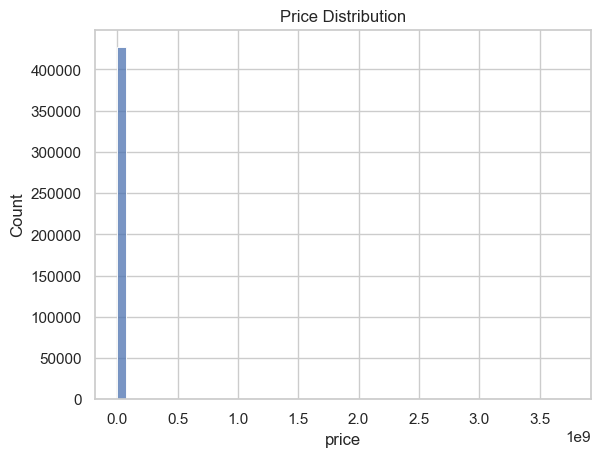

In [9]:
sns.histplot(used_cars['price'], bins=50)
plt.title("Price Distribution")
plt.show()

In [10]:
# Showing the greatest 50 values in the 'price' column to see that these are meaningless placeholders and need to be removed.
used_cars['price'].sort_values(ascending=False).head(50)

318592    3736928711
356716    3736928711
257840    3024942282
91576     3024942282
37410     3009548743
184704    1410065407
153082    1234567890
29386     1111111111
37409     1111111111
122470     987654321
280        987654321
230753     135008900
193736     123456789
288356     123456789
307488     123456789
358555     123456789
137807     123456789
207080     123456789
241404     113456789
1838        99999999
379133      25003000
136516      17000000
303644      12345678
286323      12345678
286324      12345678
303014      12345678
288401      12345678
288400      12345678
353641      11111111
300308      10004000
105843       6995495
283906       5000000
327938       3226714
68935        2000000
286156       1666666
377425       1234567
384898       1234567
377396       1234567
367308       1234567
155421       1234567
362822       1234567
384872       1234567
367357       1234567
377515       1234567
362837       1234567
194292       1234567
362867       1234567
367296       

In [11]:
# and showing the same at the low end of the 'price' column with lots of $0 values, which will be removed.
used_cars['price'].sort_values().head(100)

335266    0
97994     0
97995     0
97996     0
356355    0
         ..
356248    0
98338     0
98217     0
98219     0
356247    0
Name: price, Length: 100, dtype: int64

In [12]:
(used_cars['price'] == 0).sum()

np.int64(32895)

#### Similar to our 'price' column, we have issues with 'odometer' and 'year' columns. We have odometer readings entered as high as 10,000,000, and year as low as 1900.

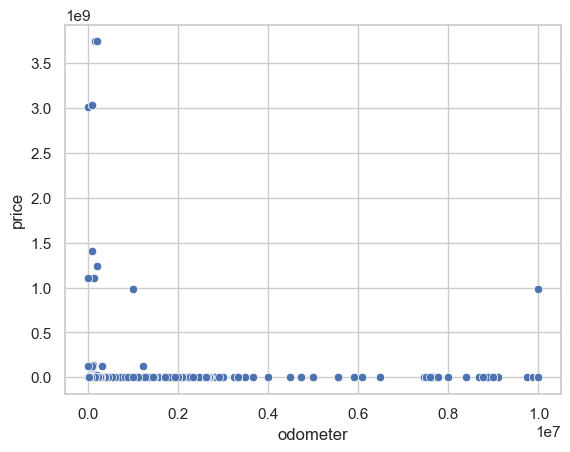

In [13]:
sns.scatterplot(x='odometer', y='price', data=used_cars)
plt.show()

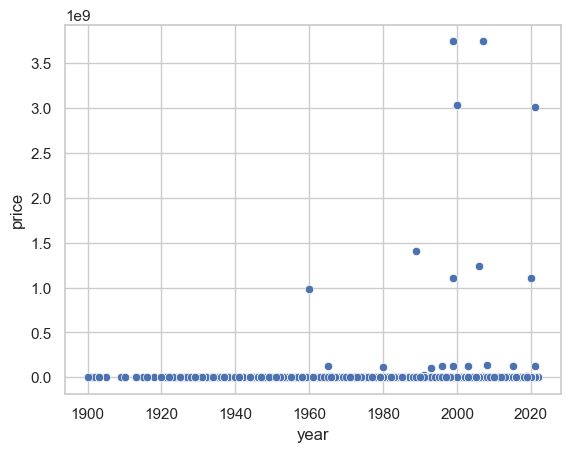

In [14]:
sns.scatterplot(x='year', y='price', data=used_cars)
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [15]:
# Making a copy of dataset to preserve the original.
used_cars_prep = used_cars.copy()

In [16]:
# I am removing prices lower than $1000, and greater than $100,000, in order eliminate outliers and unrealistic values,
# keeping what would be considered within a real-world normal range of used car values.
# Unusable 'price' entries cannot be converted to anything meaningful, as we need accurate prices to feed our model.
used_cars_prep = used_cars_prep [
    (used_cars_prep['price'] > 1000) &
    (used_cars_prep['price'] < 100000)
    ]

In [17]:
# Filtering out unrealistic odometer entries
used_cars_prep = used_cars_prep[
    (used_cars_prep['odometer'] > 0) &
    (used_cars_prep['odometer'] < 300000)
]

In [18]:
# Dropping columns id and VIN, as these are not necessary for our model, and 'size' because there is too much
# missing data.
used_cars_prep = used_cars_prep.drop(columns=['id', 'VIN', 'size'])

In [19]:
# Creating a new column identifying the age of the vehicle to help our model, and dropping entries with missing 'year' values.
# 'Age' column will help our model, rather than using year of manufacture, as our model might not make sense of this.
used_cars_prep = used_cars_prep.dropna(subset=['year'])

used_cars_prep['age'] = 2026 - used_cars_prep['year']

In [20]:
# Filling missing values in the following object columns with 'unknown' so as to keep the exisitng values, as they should be useful,
# and also help us determine whether knowing these values or not has a significant impact on our prices.
categorical_fill_unknown = [
    'condition',
    'cylinders',
    'drive',
    'type',
    'paint_color',
    'title_status'
]

for col in categorical_fill_unknown:
    used_cars_prep[col] = used_cars_prep[col].fillna('unknown')

In [21]:
# For 'fuel' and 'transmission' missing data, we are filling it with the average from these columns, as relative missing values are low,
# we can keep and use these columns as they are important, and there won't be a significant impact to our model.
used_cars_prep['fuel'] = used_cars_prep['fuel'].fillna(used_cars_prep['fuel'].mode()[0])
used_cars_prep['transmission'] = used_cars_prep['transmission'].fillna(used_cars_prep['transmission'].mode()[0])

In [22]:
used_cars_prep['cylinders'] = used_cars_prep['cylinders'].astype(str).str.extract(r'(\d+)')
used_cars_prep['cylinders'] = used_cars_prep['cylinders'].fillna('unknown')

In [23]:
used_cars_prep.info()
used_cars_prep.isnull().sum()
used_cars_prep.shape

<class 'pandas.core.frame.DataFrame'>
Index: 371787 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        371787 non-null  object 
 1   price         371787 non-null  int64  
 2   year          371787 non-null  float64
 3   manufacturer  359135 non-null  object 
 4   model         367684 non-null  object 
 5   condition     371787 non-null  object 
 6   cylinders     371787 non-null  object 
 7   fuel          371787 non-null  object 
 8   odometer      371787 non-null  float64
 9   title_status  371787 non-null  object 
 10  transmission  371787 non-null  object 
 11  drive         371787 non-null  object 
 12  type          371787 non-null  object 
 13  paint_color   371787 non-null  object 
 14  state         371787 non-null  object 
 15  age           371787 non-null  float64
dtypes: float64(3), int64(1), object(12)
memory usage: 48.2+ MB


(371787, 16)

In [24]:
used_cars_prep['manufacturer'] = used_cars_prep['manufacturer'].fillna('unknown')
used_cars_prep['model'] = used_cars_prep['model'].fillna('unknown')

In [25]:
used_cars_prep.info()
used_cars_prep.isnull().sum()
used_cars_prep.shape

<class 'pandas.core.frame.DataFrame'>
Index: 371787 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        371787 non-null  object 
 1   price         371787 non-null  int64  
 2   year          371787 non-null  float64
 3   manufacturer  371787 non-null  object 
 4   model         371787 non-null  object 
 5   condition     371787 non-null  object 
 6   cylinders     371787 non-null  object 
 7   fuel          371787 non-null  object 
 8   odometer      371787 non-null  float64
 9   title_status  371787 non-null  object 
 10  transmission  371787 non-null  object 
 11  drive         371787 non-null  object 
 12  type          371787 non-null  object 
 13  paint_color   371787 non-null  object 
 14  state         371787 non-null  object 
 15  age           371787 non-null  float64
dtypes: float64(3), int64(1), object(12)
memory usage: 48.2+ MB


(371787, 16)

In [26]:
# Dropping 'year' column now that we have new column for 'age'.
used_cars_prep = used_cars_prep.drop(columns=['year'])

In [77]:
# Reviewing cleaned data
used_cars_prep.info()
used_cars_prep.isnull().sum()
used_cars_prep.shape

<class 'pandas.core.frame.DataFrame'>
Index: 371787 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        371787 non-null  object 
 1   price         371787 non-null  int64  
 2   manufacturer  371787 non-null  object 
 3   model         371787 non-null  object 
 4   condition     371787 non-null  object 
 5   cylinders     371787 non-null  object 
 6   fuel          371787 non-null  object 
 7   odometer      371787 non-null  float64
 8   title_status  371787 non-null  object 
 9   transmission  371787 non-null  object 
 10  drive         371787 non-null  object 
 11  type          371787 non-null  object 
 12  paint_color   371787 non-null  object 
 13  state         371787 non-null  object 
 14  age           371787 non-null  float64
dtypes: float64(2), int64(1), object(12)
memory usage: 45.4+ MB


(371787, 15)

In [28]:
# Reviewing dataset after cleaning.
used_cars_prep.sample(10)

,region,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,age
400093,bellingham,11500,toyota,rav4,unknown,unknown,gas,101503.0,clean,automatic,4wd,SUV,unknown,wa,16.0
41129,orange county,17999,mercedes-benz,cla,unknown,4,gas,69910.0,clean,automatic,fwd,sedan,black,ca,12.0
126385,northwest GA,8750,unknown,Sterling,excellent,8,diesel,250000.0,clean,automatic,rwd,truck,white,ga,24.0
283761,new hampshire,13900,ford,f350 xl,unknown,unknown,gas,59000.0,clean,automatic,unknown,unknown,unknown,nh,18.0
44999,palm springs,3999,honda,civic ex,fair,4,gas,176872.0,clean,manual,unknown,coupe,unknown,ca,19.0
196239,detroit metro,5995,chevrolet,cruze,unknown,unknown,gas,124254.0,clean,automatic,unknown,unknown,unknown,mi,13.0
298431,dayton / springfield,13999,honda,accord,unknown,unknown,gas,72830.0,clean,automatic,unknown,sedan,black,oh,11.0
68507,ventura county,13517,honda,civic lx sedan 4d,excellent,4,gas,64562.0,unknown,automatic,unknown,sedan,unknown,ca,10.0
243032,raleigh / durham / CH,31995,ram,2500,unknown,8,gas,111789.0,clean,automatic,4wd,truck,white,nc,9.0
189714,western massachusetts,6500,mazda,6,excellent,4,gas,133000.0,clean,automatic,rwd,sedan,grey,ma,16.0


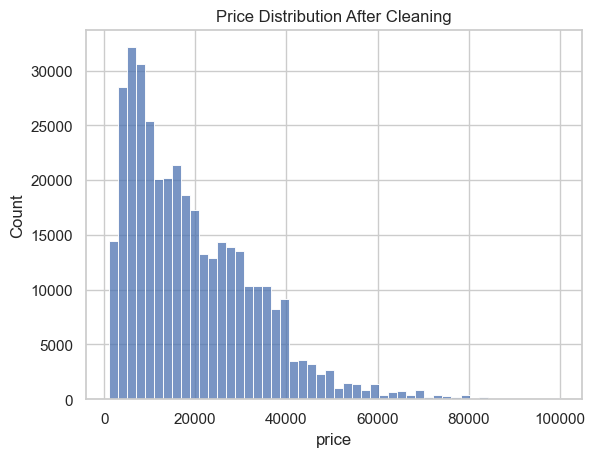

In [29]:
# Plotting our Price Distribution after cleaning data, we have a skewed right graph.
sns.histplot(used_cars_prep['price'], bins=50)
plt.title("Price Distribution After Cleaning")
plt.show()

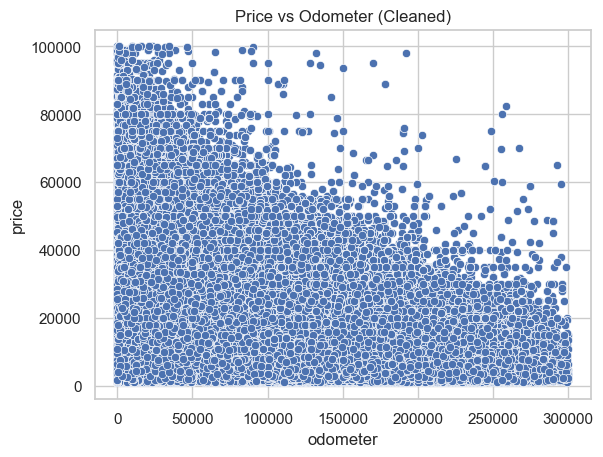

In [30]:
# Plotting the relationship between price and mileage after cleaning.
sns.scatterplot(x='odometer', y='price', data=used_cars_prep)
plt.title("Price vs Odometer (Cleaned)")
plt.show()

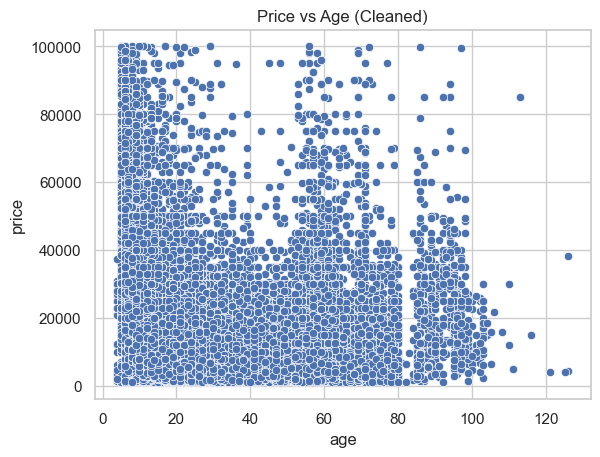

In [31]:
# And plotting relationship between price and age of vehicle after cleaining.
sns.scatterplot(x='age', y='price', data=used_cars_prep)
plt.title("Price vs Age (Cleaned)")
plt.show()

In [78]:
# Checking unique values and dtypes after cleaning to help determine other columns to drop. 
# In this case I will drop 'model' and 'region' as there are too many unique object values that might not pertain to our model.
df_summary = used_cars_prep.nunique().to_frame(name='nunique')
df_summary['dtype'] = used_cars_prep.dtypes

df_summary.sort_values(by='nunique', ascending=False)

,nunique,dtype
odometer,95002,float64
model,26159,object
price,14420,int64
region,404,object
age,111,float64
state,51,object
manufacturer,43,object
type,14,object
paint_color,13,object
cylinders,8,object


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [79]:
# Creating copy of our preppeed dataset to model
df_model = used_cars_prep.copy()
# Dropping 'model' and 'region' columns as decided on above
df_model = df_model.drop(columns=['model', 'region'])
# Using One Hot Encoding on Categorical Variables to convert into binary indicators for our model.
df_encoded = pd.get_dummies(df_model, drop_first=True)
df_encoded

,price,odometer,age,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
27,33590,57923.0,12.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
28,22590,71229.0,16.0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
29,39590,19160.0,6.0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
30,30990,41124.0,9.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31,15000,128000.0,13.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,23590,32226.0,7.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
426876,30590,12029.0,6.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
426877,34990,4174.0,6.0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
426878,28990,30112.0,8.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [34]:
# Our encoded dataframe has 371,787 rows and 148 columns.
df_encoded.shape

(371787, 148)

In [35]:
df_encoded.dtypes.value_counts()

bool       145
float64      2
int64        1
Name: count, dtype: int64

In [36]:
# Preparation for Train Test Split.
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.3, random_state=42)

### Linear Regression

In [80]:
# Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Identifying coefficients as they relate to the baseline in feature category to showcase what features have most significant impact on price.
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
})

coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coef
12,manufacturer_ferrari,42846.847147,42846.847147
57,fuel_electric,-19052.920663,19052.920663
39,manufacturer_tesla,17145.556756,17145.556756
59,fuel_hybrid,-14865.619944,14865.619944
58,fuel_gas,-14700.781588,14700.781588
16,manufacturer_harley-davidson,-12645.782153,12645.782153
60,fuel_other,-11688.622534,11688.622534
51,cylinders_3,-10419.598412,10419.598412
13,manufacturer_fiat,-9642.199886,9642.199886
34,manufacturer_porsche,9022.967897,9022.967897


In [82]:
preds = model.predict(X_test)

In [83]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 8583.296600360047


In [41]:
# Average price
# My RMSE of $8583 is 44% of average price of $19,396 using Linear Regression
df_encoded['price'].mean()

np.float64(19395.93267112621)

### Ridge Regression

In [91]:
# Moving onto Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

preds_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, preds_ridge))

print("Ridge RMSE:", rmse_ridge)

Ridge RMSE: 8583.308163307423


In [92]:
for a in [0.01, 0.1, 1, 10, 100, 1000]:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    
    preds = ridge.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    print(f"alpha={a}, RMSE={rmse}")

alpha=0.01, RMSE=8583.296445223466
alpha=0.1, RMSE=8583.295326344538
alpha=1, RMSE=8583.308163307423
alpha=10, RMSE=8584.491774934542
alpha=100, RMSE=8598.152019341966
alpha=1000, RMSE=8683.651862422765


### Cross Validation with K Fold

In [94]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    scoring='neg_mean_squared_error',
    cv=kf
)

rmse_scores = np.sqrt(-scores)

print("RMSE per fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE per fold: [8613.69497391 8527.29241327 8561.08585792 8481.29150106 8592.93015019]
Average RMSE: 8555.258979268208


### Comparing Train RMSE vs Test RMSE for Linear, Ridge, and Lasso

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model_diag = LinearRegression()
model_diag.fit(X_train, y_train)

train_preds = model_diag.predict(X_train)
test_preds = model_diag.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 8536.67488782081
Test RMSE: 8583.296600360047


In [96]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

ridge_diag = Ridge(alpha=0.1)
ridge_diag.fit(X_train, y_train)

# Predictions
ridge_train_preds = ridge_diag.predict(X_train)
ridge_test_preds = ridge_diag.predict(X_test)

# RMSE
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_preds))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_preds))

print("Ridge Train RMSE:", ridge_train_rmse)
print("Ridge Test RMSE:", ridge_test_rmse)

Ridge Train RMSE: 8536.675077645123
Ridge Test RMSE: 8583.295326344538


In [97]:
from sklearn.linear_model import Lasso

lasso_diag = Lasso(alpha=0.1, max_iter=10000)
lasso_diag.fit(X_train, y_train)

# Predictions
lasso_train_preds = lasso_diag.predict(X_train)
lasso_test_preds = lasso_diag.predict(X_test)

# RMSE
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, lasso_train_preds))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_preds))

print("Lasso Train RMSE:", lasso_train_rmse)
print("Lasso Test RMSE:", lasso_test_rmse)

Lasso Train RMSE: 8536.733263970644
Lasso Test RMSE: 8583.232493291089


### Comparing the Models

In [98]:
print("--- Model Comparison ---")
print("Linear Train RMSE:", train_rmse)
print("Linear Test RMSE:", test_rmse)
print("Ridge Train RMSE:", ridge_train_rmse)
print("Ridge Test RMSE:", ridge_test_rmse)
print("Lasso Train RMSE:", lasso_train_rmse)
print("Lasso Test RMSE:", lasso_test_rmse)

--- Model Comparison ---
Linear Train RMSE: 8536.67488782081
Linear Test RMSE: 8583.296600360047
Ridge Train RMSE: 8536.675077645123
Ridge Test RMSE: 8583.295326344538
Lasso Train RMSE: 8536.733263970644
Lasso Test RMSE: 8583.232493291089


#### Viewing some unique entries to showcase baselines, the first entry in each respective category, which will be useful for our next plot. 

In [45]:
sorted(used_cars_prep['manufacturer'].unique())

['acura',
 'alfa-romeo',
 'aston-martin',
 'audi',
 'bmw',
 'buick',
 'cadillac',
 'chevrolet',
 'chrysler',
 'datsun',
 'dodge',
 'ferrari',
 'fiat',
 'ford',
 'gmc',
 'harley-davidson',
 'honda',
 'hyundai',
 'infiniti',
 'jaguar',
 'jeep',
 'kia',
 'land rover',
 'lexus',
 'lincoln',
 'mazda',
 'mercedes-benz',
 'mercury',
 'mini',
 'mitsubishi',
 'morgan',
 'nissan',
 'pontiac',
 'porsche',
 'ram',
 'rover',
 'saturn',
 'subaru',
 'tesla',
 'toyota',
 'unknown',
 'volkswagen',
 'volvo']

In [46]:
sorted(used_cars_prep['fuel'].unique())

['diesel', 'electric', 'gas', 'hybrid', 'other']

In [47]:
(used_cars_prep['fuel'] == 'other').sum()

np.int64(27033)

In [48]:
sorted(used_cars_prep['cylinders'].unique())

['10', '12', '3', '4', '5', '6', '8', 'unknown']

In [49]:
sorted(used_cars_prep['condition'].unique())

['excellent', 'fair', 'good', 'like new', 'new', 'salvage', 'unknown']

In [50]:
sorted(used_cars_prep['title_status'].unique())

['clean', 'lien', 'missing', 'parts only', 'rebuilt', 'salvage', 'unknown']

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

##### Our results between Linear Regression, Ridge Regression, and Lasso, were nearly identical, which showcases that the first model, Linear Regression, was stable, and our model was not overfitting. Regularization did not improve performance of the model. With Cross Validation, the average RMSE was 8555, which is within the range of our other models. 

##### The fact that our RMSEs are approximately 44% of the average used car price of $19,396 tells us a story that used car prices are rather challenging and complex to predict with great accuracy, and there are many factors and variables involved, as we can see from our dataset, and as we will see from our evaluation.

##### Our findings indicate that there are many features that impact used car prices, and as we can see from the following 2 graphs, manufacturer, fuel type (diesel, gas, electric, hybrid), and engine size impact price significantly.

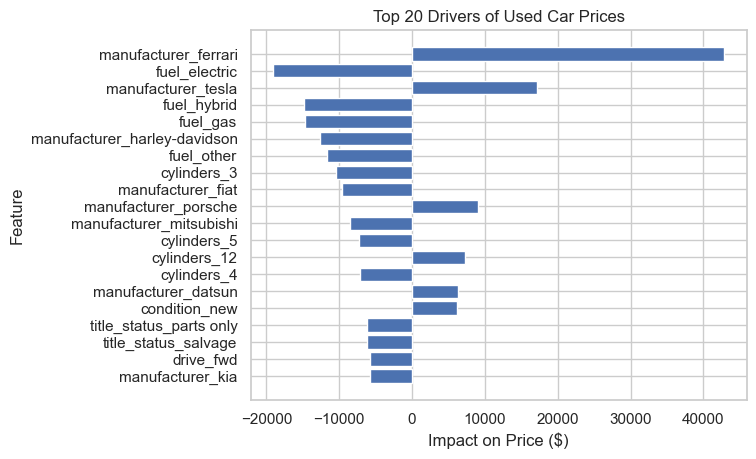

In [51]:
import matplotlib.pyplot as plt

top_features = coef_df.head(20)

plt.figure()
plt.barh(top_features['feature'], top_features['coefficient'])
plt.gca().invert_yaxis()

plt.title("Top 20 Drivers of Used Car Prices")
plt.xlabel("Impact on Price ($)")
plt.ylabel("Feature")

plt.show()

In [52]:
def categorize_feature(feature):
    if 'manufacturer' in feature:
        return 'Manufacturer'
    elif 'fuel' in feature:
        return 'Fuel Type'
    elif 'cylinders' in feature:
        return 'Engine Size'
    elif 'condition' in feature:
        return 'Condition'
    elif 'title_status' in feature:
        return 'Title Status'
    elif 'drive' in feature:
        return 'Drivetrain'
    else:
        return 'Other'

coef_df['category'] = coef_df['feature'].apply(categorize_feature)

In [53]:
category_impact = (
    coef_df.groupby('category')['abs_coef']
    .max()
    .sort_values()
)

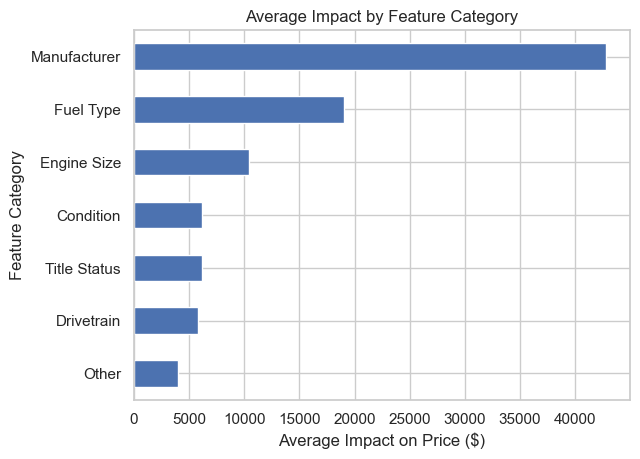

In [54]:
import matplotlib.pyplot as plt

plt.figure()
category_impact.plot(kind='barh')

plt.title("Average Impact by Feature Category")
plt.xlabel("Average Impact on Price ($)")
plt.ylabel("Feature Category")

plt.show()

### Age of the vehicle is a significant driver of price. We see a clear correlation and a steady decrease in price as vehicles age. However, we see in increase in price at about the 50 year mark, which indicates that classic cars and collectibles, from the years of 1955 to 1975 can command higher prices.

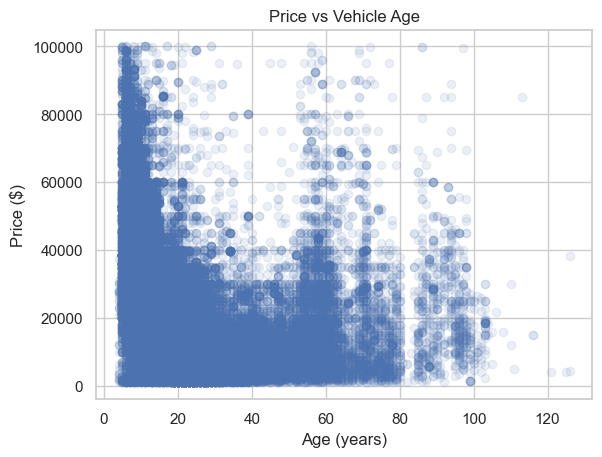

In [55]:
plt.figure()
plt.scatter(used_cars_prep['age'], used_cars_prep['price'], alpha=0.1)

plt.title("Price vs Vehicle Age")
plt.xlabel("Age (years)")
plt.ylabel("Price ($)")

plt.show()

#### There is also a clear and extremely strong correlation between vehicle price and mileage.

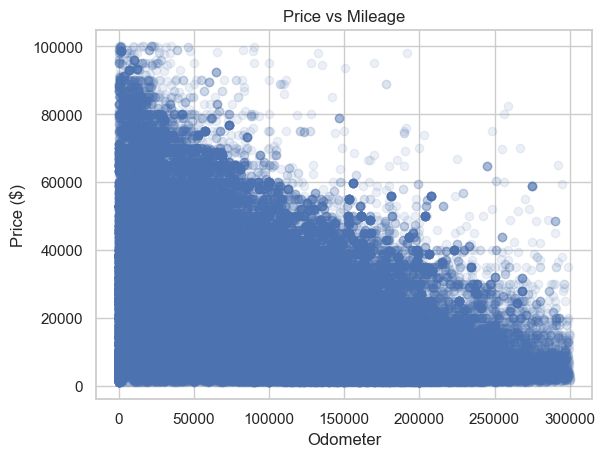

In [56]:
plt.figure()
plt.scatter(used_cars_prep['odometer'], used_cars_prep['price'], alpha=0.1)

plt.title("Price vs Mileage")
plt.xlabel("Odometer")
plt.ylabel("Price ($)")

plt.show()

#### Below is a Box Plot showcasing how prices are impacted by fuel type. Diesel has the highest median price, and electric the second highest. For entries that did not have values for 'fuel' we replaced with 'other', and we are unsure what these fuel types are. We can assume that the 'other' catagory consists of a conglomeration of gas, electric, hybrid, and diesel.

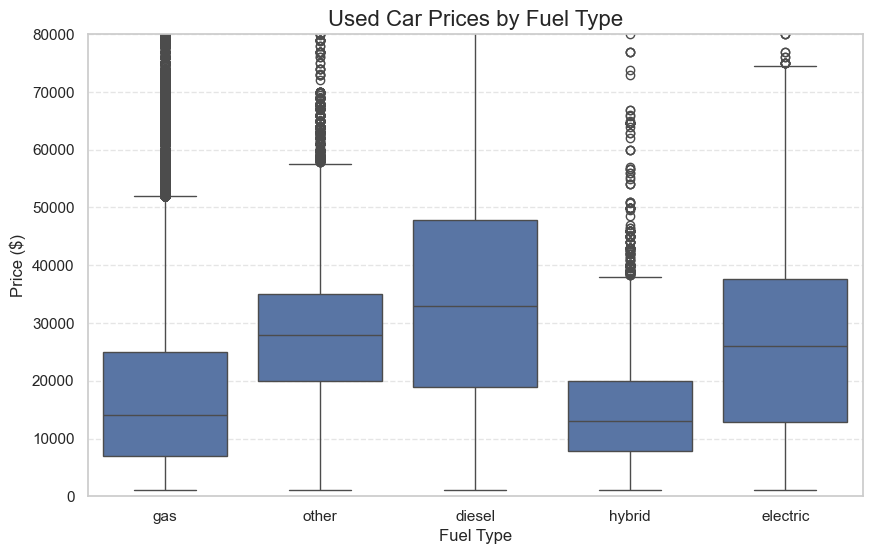

In [99]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=used_cars_prep,
    x='fuel',
    y='price'
)

plt.ylim(0, 80000)

plt.title("Used Car Prices by Fuel Type", fontsize=16)
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### The below graph showcases the 10 manufacturers with the most entries on our dataset and their average prices.

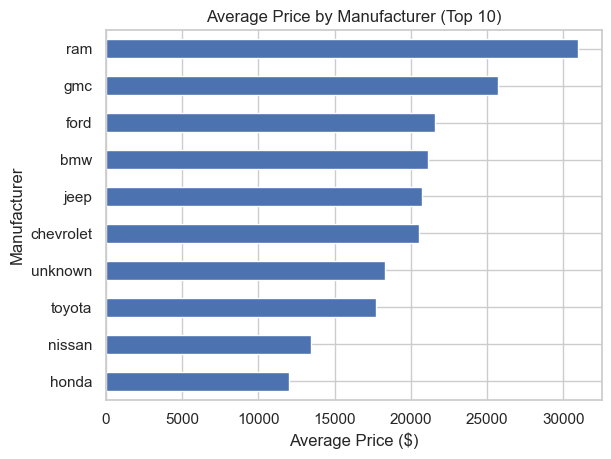

In [58]:
top_brands = used_cars_prep['manufacturer'].value_counts().head(10).index

brand_prices = used_cars_prep[
    used_cars_prep['manufacturer'].isin(top_brands)
].groupby('manufacturer')['price'].mean().sort_values()

plt.figure()
brand_prices.plot(kind='barh')

plt.title("Average Price by Manufacturer (Top 10)")
plt.xlabel("Average Price ($)")
plt.ylabel("Manufacturer")

plt.show()

#### Condition plays a crucial role in used vehicle prices as shown below.

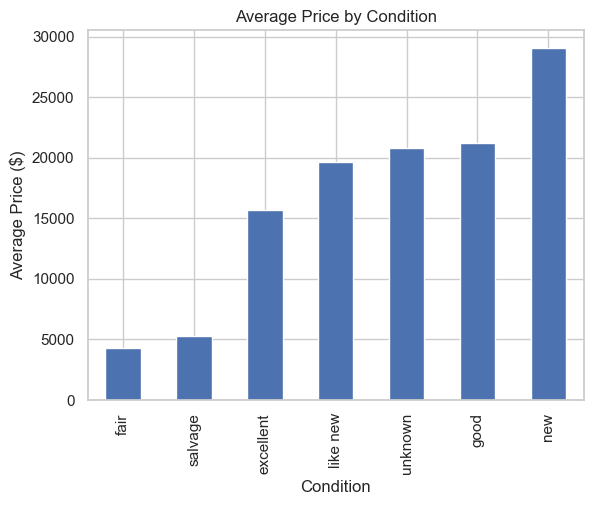

In [61]:
cond_prices = used_cars_prep.groupby('condition')['price'].mean().sort_values()

plt.figure()
cond_prices.plot(kind='bar')

plt.title("Average Price by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Price ($)")

plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

#### For the luxury focused dealers interested in supplying exotic and high ticket vehicles, we know that manufacturer is king. Imported brands such as Ferrari will command the highest prices. Keep in mind, the condition of the vehicle should be new, good, or like new, and the lower the odometer reading, the greater the value. Look for high end luxury and exotic cars to have mileage <25k for the highest prices. For cars with 25k- 50k miles, you can expect about a 20% decrease in price. There is a steady trend, that for every 20k miles, there is a decrease of $10k in price, on average.
#### For dealerships focused on mainstream vehicles, with average clientele, similar rules apply. Vehicle brand is the most significant driver of price, followed by fuel type, age of vehicle, mileage and condition. Depending on your location, if you supply customers in rural and high agriculture infrastructure areas, diesel Rams are trucks that you want in your inventory, as these remain popular, in demand, and maintain high value as used vehicles. For the urban dealerships, you will want to streamline your inventory with electric, gas, and hybrid vehicles. Higher end EV’s such as Teslas remain in demand and will yield higher prices. Again, condition, age, and mileage are critical to the price. Aim for vehicles with fewer than 100k miles, that are less than 10 years old.
#### If you’re dealing in classic cars, you’ll want to focus on vehicles from the 1950’s and 1960’s. Lower odometer readings for these cars will significantly increase price. 
#### Unless this is your dealership’s area of focus, it would be worthwhile to avoid vehicles with salvage titles, or vehicles in fair condition. These will yield the lowest prices, and stocking these in your inventory can negatively impact reputation. However, there is a space for these in the marketplace. If you plan to deal vehicles that meet these criteria, it would be advisable to design your business around providing affordable cars to clients that are seeking high mileage, salvage titles, or vehicles in lower conditions.